Autores: Josep Pérez Segura, Raul Rodríguez López Rey
# Tarea B3-T1


## 1. Importación de datos

Descargamos datos históricos de **3 criptoactivos** desde la API pública de Binance:

| # | Símbolo | Descripción |
|---|---------|-------------|
| 1 | BTCUSDT | Bitcoin |
| 2 | ETHUSDT | Ethereum |
| 3 | DOGEUSDT | Dogecoin |

- **Intervalo**: velas de 5 minutos
- **Periodo**: últimos ~5 años (marzo 2021 – marzo 2026)
- Los datos se cachean en CSV para evitar re-descargas.

**Limpieza de huecos temporales:** Todos los activos presentan un hueco de 16 velas (85 min) el 2023-03-24 entre las 12:35 y las 14:00 UTC, correspondiente a una ventana de mantenimiento programado de Binance en la que el exchange no generó velas. Para mantener la continuidad de la serie temporal se rellenan estas velas ausentes mediante *forward-fill*: se replica el último precio conocido (open, high, low, close) y se asignan volumen y número de trades a cero, ya que no hubo actividad real.

In [ ]:
%pip install requests pandas numpy matplotlib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import datetime
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

In [ ]:
# --- Configuración ---
SYMBOLS = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "DOGEUSDT",  # Dogecoin
]

INTERVAL = "5m"
BASE_URL = "https://api.binance.com/api/v3/klines"

START_DATE = datetime.datetime(2021, 3, 17)
END_DATE = datetime.datetime(2026, 3, 17)
START_MS = int(START_DATE.timestamp() * 1000)
END_MS = int(END_DATE.timestamp() * 1000)

LIMIT = 1000
SLEEP_BETWEEN = 0.05

DATA_DIR = Path("data")

print(f"Periodo: {START_DATE.date()} -> {END_DATE.date()}")
print(f"Intervalo: {INTERVAL}")
print(f"Activos: {len(SYMBOLS)}")
for s in SYMBOLS:
    print(f"  - {s}")

Periodo: 2021-03-17 -> 2026-03-17
Intervalo: 5m
Activos: 3
  - BTCUSDT
  - ETHUSDT
  - DOGEUSDT


In [ ]:
def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    """Descarga velas de Binance con paginación automática."""
    session = requests.Session()
    all_klines = []
    current_ms = start_ms

    # Estimar número de requests para la barra de progreso
    interval_ms = 5 * 60 * 1000  # 5 minutos en ms
    estimated_requests = (end_ms - start_ms) // (limit * interval_ms) + 1

    pbar = tqdm(total=estimated_requests, desc="Descargando velas")

    while current_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ms,
            "endTime": end_ms,
            "limit": limit,
        }

        resp = session.get(BASE_URL, params=params)

        # Manejo de rate limiting
        if resp.status_code in (429, 418):
            retry_after = int(resp.headers.get("Retry-After", 5))
            print(f"Rate limited. Esperando {retry_after}s...")
            time.sleep(retry_after)
            continue

        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_klines.extend(data)

        # Avanzar: close_time del último registro + 1 ms
        current_ms = data[-1][6] + 1
        pbar.update(1)

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    print(f"Total velas descargadas: {len(all_klines):,}")
    return all_klines

In [ ]:
# --- Descarga / carga de todos los activos ---
DATA_DIR.mkdir(exist_ok=True)

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_volume", "num_trades",
    "taker_buy_base_vol", "taker_buy_quote_vol", "ignore",
]
numeric_cols = ["open", "high", "low", "close", "volume",
                "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]

dfs = {}  # diccionario {symbol: DataFrame}

for symbol in SYMBOLS:
    csv_path = DATA_DIR / f"{symbol}_{INTERVAL}_5y.csv"

    if csv_path.exists():
        print(f"[{symbol}] Cargando desde cache: {csv_path}")
        dfs[symbol] = pd.read_csv(csv_path, parse_dates=["open_time", "close_time"])
    else:
        print(f"[{symbol}] Descargando de Binance API...")
        raw = fetch_klines(symbol, INTERVAL, START_MS, END_MS, LIMIT)

        tmp = pd.DataFrame(raw, columns=columns)
        tmp[numeric_cols] = tmp[numeric_cols].astype(float)
        tmp["num_trades"] = tmp["num_trades"].astype(int)
        tmp["open_time"] = pd.to_datetime(tmp["open_time"], unit="ms")
        tmp["close_time"] = pd.to_datetime(tmp["close_time"], unit="ms")
        tmp.drop(columns=["ignore"], inplace=True)

        tmp.drop_duplicates(subset=["open_time"], inplace=True)
        tmp.sort_values("open_time", inplace=True)
        tmp.reset_index(drop=True, inplace=True)

        tmp = tmp[(tmp["open_time"] >= str(START_DATE)) &
                  (tmp["open_time"] < str(END_DATE))]
        tmp.reset_index(drop=True, inplace=True)

        tmp.to_csv(csv_path, index=False)
        size_mb = csv_path.stat().st_size / 1e6
        print(f"  -> Guardado: {csv_path} ({len(tmp):,} filas, {size_mb:.1f} MB)")

        dfs[symbol] = tmp

# df principal = BTCUSDT (compatibilidad con el resto del notebook)
df = dfs["BTCUSDT"]

print(f"\n{'='*60}")
print(f"Resumen de descarga:")
for sym, d in dfs.items():
    print(f"  {sym:10s} -> {d.shape[0]:>10,} filas | {d['open_time'].min().date()} - {d['open_time'].max().date()}")
print(f"{'='*60}")

[BTCUSDT] Cargando desde cache: data\BTCUSDT_5m_5y.csv
[ETHUSDT] Cargando desde cache: data\ETHUSDT_5m_5y.csv
[DOGEUSDT] Cargando desde cache: data\DOGEUSDT_5m_5y.csv

Resumen de descarga:
  BTCUSDT    ->    525,697 filas | 2021-03-17 - 2026-03-16
  ETHUSDT    ->    525,697 filas | 2021-03-17 - 2026-03-16
  DOGEUSDT   ->    525,697 filas | 2021-03-17 - 2026-03-16


In [ ]:
# --- Forward-fill de huecos temporales (16 velas ausentes por mantenimiento de Binance) ---
for sym in dfs:
    d = dfs[sym].set_index("open_time")
    full_idx = pd.date_range(d.index.min(), d.index.max(), freq="5min", name="open_time")
    d = d.reindex(full_idx)

    # Precios: forward-fill (último precio conocido)
    price_cols = ["open", "high", "low", "close"]
    d[price_cols] = d[price_cols].ffill()

    # close_time: recalcular como open_time + 5min - 1ms
    d["close_time"] = d.index + pd.Timedelta(minutes=5) - pd.Timedelta(milliseconds=1)

    # Volumen y trades: 0 en velas sintéticas (no hubo actividad)
    vol_cols = ["volume", "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]
    d[vol_cols] = d[vol_cols].fillna(0.0)
    d["num_trades"] = d["num_trades"].fillna(0).astype(int)

    d = d.reset_index()
    dfs[sym] = d

df = dfs["BTCUSDT"]

print(f"Forward-fill completado. Verificación de huecos restantes:")
for sym, d in dfs.items():
    gaps = d["open_time"].diff().dt.total_seconds().dropna()
    n_gaps = (gaps != 300).sum()
    print(f"  {sym:10s} -> {d.shape[0]:>10,} filas | huecos: {n_gaps}")

Forward-fill completado. Verificación de huecos restantes:
  BTCUSDT    ->    525,877 filas | huecos: 0
  ETHUSDT    ->    525,877 filas | huecos: 0
  DOGEUSDT   ->    525,877 filas | huecos: 0


In [ ]:
# --- Verificación y exploración ---
for sym, d in dfs.items():
    print(f"\n{'─'*50}")
    print(f"  {sym}")
    print(f"  Periodo: {d['open_time'].min()} -> {d['open_time'].max()}")
    print(f"  Memoria: {d.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print(f"  Shape:   {d.shape}")

    deltas = d["open_time"].diff().dt.total_seconds().dropna()
    gaps = deltas[deltas != 300]
    print(f"  Huecos temporales (intervalos != 5 min): {len(gaps)} de {len(deltas)}")

print(f"\n{'─'*50}")
print("\nDetalle BTCUSDT (df principal):")
display(df.describe())



──────────────────────────────────────────────────
  BTCUSDT
  Periodo: 2021-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 46.3 MB
  Shape:   (525877, 11)
  Huecos temporales (intervalos != 5 min): 0 de 525876

──────────────────────────────────────────────────
  ETHUSDT
  Periodo: 2021-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 46.3 MB
  Shape:   (525877, 11)
  Huecos temporales (intervalos != 5 min): 0 de 525876

──────────────────────────────────────────────────
  DOGEUSDT
  Periodo: 2021-03-17 00:00:00 -> 2026-03-16 23:00:00
  Memoria: 46.3 MB
  Shape:   (525877, 11)
  Huecos temporales (intervalos != 5 min): 0 de 525876

──────────────────────────────────────────────────

Detalle BTCUSDT (df principal):


,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
count,525877,525877.000000,525877.000000,525877.000000,525877.000000,525877.000000,525877,5.258770e+05,525877.000000,525877.000000,5.258770e+05
mean,2023-09-15 23:30:00.000001536,55842.228947,55897.955752,55785.697099,55842.282868,248.755366,2023-09-15 23:34:59.998998784,8.982756e+06,10275.182775,123.097557,4.428224e+06
min,2021-03-17 00:00:00,15590.570000,15633.310000,15476.000000,15593.580000,0.000000,2021-03-17 00:04:59.999000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2022-06-16 11:45:00,29416.810000,29429.700000,29402.430000,29416.820000,48.463249,2022-06-16 11:49:59.999000064,2.733048e+06,3122.000000,22.169650,1.253306e+06
50%,2023-09-15 23:30:00,48348.660000,48418.190000,48283.500000,48348.060000,101.498290,2023-09-15 23:34:59.999000064,5.319207e+06,5890.000000,49.335550,2.568190e+06
75%,2024-12-15 11:15:00,73446.450000,73545.170000,73339.540000,73446.770000,246.833540,2024-12-15 11:19:59.999000064,1.058998e+07,12880.000000,122.895340,5.245555e+06
max,2026-03-16 23:00:00,126011.180000,126199.630000,125868.130000,126011.180000,15659.934840,2026-03-16 23:04:59.999000,5.588519e+08,711259.000000,8884.511430,2.663202e+08
std,NaN,29750.428274,29769.739500,29730.507647,29750.432163,450.694440,NaN,1.214962e+07,12180.433283,225.767761,6.165944e+06


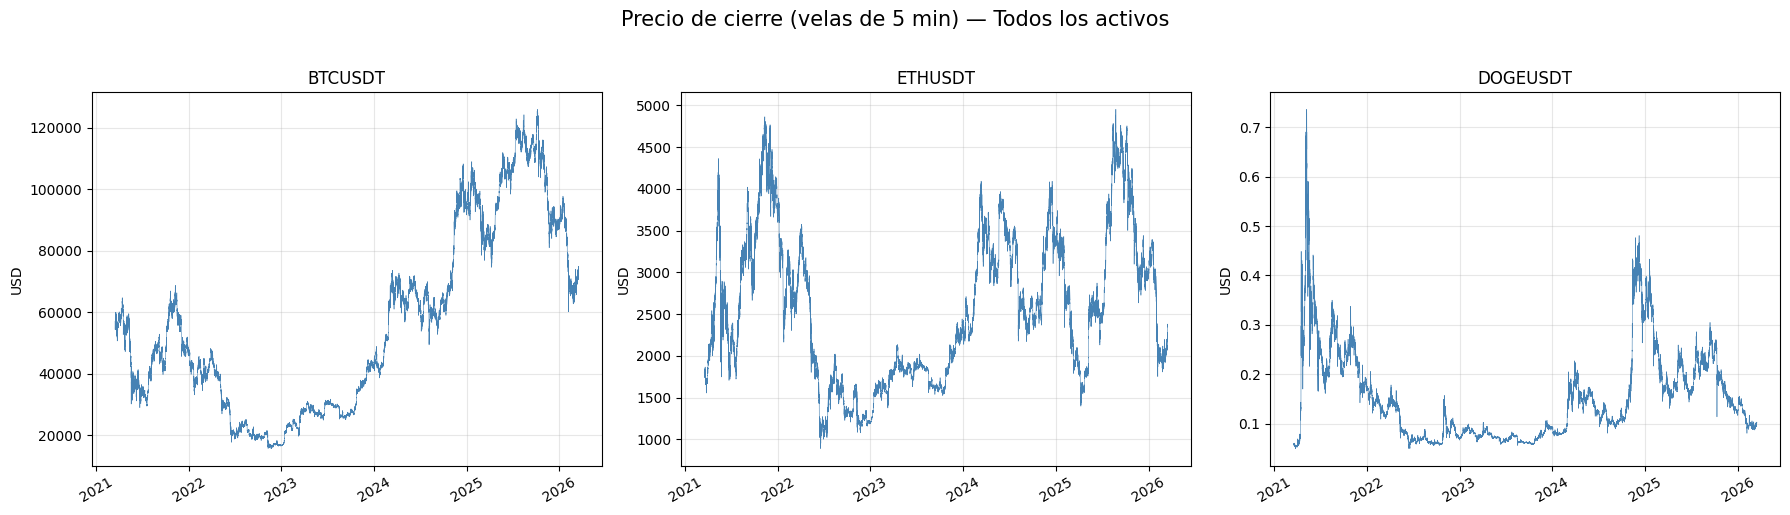

In [ ]:
# --- Evolución del precio de todos los criptoactivos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (sym, d) in zip(axes.flat, dfs.items()):
    ax.plot(d["open_time"], d["close"], linewidth=0.4, color="steelblue")
    ax.set_title(sym, fontsize=12)
    ax.set_ylabel("USD")
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Precio de cierre (velas de 5 min) — Todos los activos", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 2. Barras alternativas: Dollar Bars, Volume Bars y Tick Bars

Las barras basadas en tiempo (time bars) presentan propiedades estadísticas indeseables: autocorrelación, heterocedasticidad y distribuciones no normales. Lopez de Prado (2018, Cap. 2) propone muestrear los datos usando **barras alternativas** que se cierran al alcanzar un umbral acumulado:

- **Tick Bars**: se cierra una barra cada N operaciones (trades). Muestrean según la actividad del mercado.
- **Volume Bars**: se cierra una barra cada V unidades de volumen (BTC). Normalizan la información por volumen negociado.
- **Dollar Bars**: se cierra una barra cada D dólares negociados (quote volume en USDT). Son las más robustas según MLdP, ya que normalizan por valor económico real.

Al usar velas de 5 min como proxy, cada vela aporta: `num_trades` (ticks), `volume` (BTC), y `quote_volume` (USDT). Acumulamos estos valores y generamos una nueva barra OHLCV cada vez que se supera el umbral.

Compararemos **3 umbrales distintos** para cada tipo de barra para ilustrar el efecto del parámetro.

In [ ]:
def make_bars(df, metric_col, threshold):
    """
    Genera barras alternativas agrupando filas hasta que la suma acumulada
    de `metric_col` supera `threshold`.

    Parámetros:
        df: DataFrame con columnas open_time, open, high, low, close, volume,
            quote_volume, num_trades y la columna `metric_col`.
        metric_col: columna a acumular ('num_trades', 'volume', 'quote_volume').
        threshold: valor umbral para cerrar cada barra.

    Retorna:
        DataFrame con barras OHLCV + timestamp.
    """
    bars = []
    cum_metric = 0.0
    open_price = df.iloc[0]["open"]
    high_price = -np.inf
    low_price = np.inf
    cum_volume = 0.0
    cum_quote_volume = 0.0
    cum_trades = 0
    bar_start = df.iloc[0]["open_time"]

    for _, row in df.iterrows():
        high_price = max(high_price, row["high"])
        low_price = min(low_price, row["low"])
        cum_volume += row["volume"]
        cum_quote_volume += row["quote_volume"]
        cum_trades += row["num_trades"]
        cum_metric += row[metric_col]

        if cum_metric >= threshold:
            bars.append({
                "open_time": bar_start,
                "close_time": row["close_time"],
                "open": open_price,
                "high": high_price,
                "low": low_price,
                "close": row["close"],
                "volume": cum_volume,
                "quote_volume": cum_quote_volume,
                "num_trades": cum_trades,
            })
            # Reset
            cum_metric = 0.0
            cum_volume = 0.0
            cum_quote_volume = 0.0
            cum_trades = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = row["close"]
            bar_start = row["close_time"]

    return pd.DataFrame(bars)

In [ ]:
# --- Calcular estadísticas para elegir umbrales razonables ---
print("Estadísticas por vela de 5 min:")
print(f"  num_trades  -> media: {df['num_trades'].mean():,.0f}, mediana: {df['num_trades'].median():,.0f}")
print(f"  volume (BTC)-> media: {df['volume'].mean():,.1f}, mediana: {df['volume'].median():,.1f}")
print(f"  quote_vol ($)-> media: {df['quote_volume'].mean():,.0f}, mediana: {df['quote_volume'].median():,.0f}")

# Umbrales: elegidos para generar ~5K, ~15K y ~50K barras aprox.
total_trades = df["num_trades"].sum()
total_volume = df["volume"].sum()
total_dollar = df["quote_volume"].sum()

tick_thresholds = [
    int(total_trades / 50_000),
    int(total_trades / 15_000),
    int(total_trades / 5_000),
]
volume_thresholds = [
    round(total_volume / 50_000, 0),
    round(total_volume / 15_000, 0),
    round(total_volume / 5_000, 0),
]
dollar_thresholds = [
    round(total_dollar / 50_000, -3),
    round(total_dollar / 15_000, -3),
    round(total_dollar / 5_000, -3),
]

print(f"\nUmbrales Tick Bars:   {tick_thresholds} trades")
print(f"Umbrales Volume Bars: {volume_thresholds} BTC")
print(f"Umbrales Dollar Bars: {dollar_thresholds} USDT")

Estadísticas por vela de 5 min:
  num_trades  -> media: 10,275, mediana: 5,890
  volume (BTC)-> media: 248.8, mediana: 101.5
  quote_vol ($)-> media: 8,982,756, mediana: 5,319,207

Umbrales Tick Bars:   [108069, 360232, 1080696] trades
Umbrales Volume Bars: [np.float64(2616.0), np.float64(8721.0), np.float64(26163.0)] BTC
Umbrales Dollar Bars: [np.float64(94476000.0), np.float64(314922000.0), np.float64(944765000.0)] USDT


Estas estadísticas nos dan una referencia para elegir los umbrales. La idea es: una barra se cierra cuando la suma acumulada de la métrica (trades, volumen o USD) supera un umbral. Si el umbral es bajo, se generan muchas barras pequeñas; si es alto, pocas barras pero con más información cada una.

In [11]:
# --- Generar las barras alternativas ---
print("Generando barras... (puede tardar unos segundos por cada umbral)\n")

bar_results = {}

for label, col, thresholds in [
    ("Tick Bars", "num_trades", tick_thresholds),
    ("Volume Bars", "volume", volume_thresholds),
    ("Dollar Bars", "quote_volume", dollar_thresholds),
]:
    bar_results[label] = {}
    for th in thresholds:
        bars_df = make_bars(df, col, th)
        bar_results[label][th] = bars_df
        print(f"  {label} (umbral={th:,.0f}): {len(bars_df):,} barras")
    print()

Generando barras... (puede tardar unos segundos por cada umbral)

  Tick Bars (umbral=108,069): 45,181 barras
  Tick Bars (umbral=360,232): 14,512 barras
  Tick Bars (umbral=1,080,696): 4,944 barras

  Volume Bars (umbral=2,616): 42,713 barras
  Volume Bars (umbral=8,721): 14,192 barras


KeyboardInterrupt: 

Probamos 3 umbrales (bajo, medio, alto) por tipo de barra. El número de barras es inversamente proporcional al umbral: $N \approx \sum x_t \,/\, \theta$. El objetivo es encontrar el punto donde los retornos $r_j = \ln(C_j / C_{j-1})$ se comportan lo más parecido posible a un proceso IID gaussiano.

In [ ]:
# --- Grafica comparativa: retornos y autocorrelacion para cada tipo de barra ---
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    for col_idx, (th, bars_df) in enumerate(thresholds_dict.items()):
        ax = axes[row_idx, col_idx]
        returns = bars_df["close"].pct_change().dropna()
        ax.hist(returns, bins=150, alpha=0.7, density=True, color="steelblue", edgecolor="none")

        # Estadisticas en el titulo
        ax.set_title(
            f"{bar_type} (umbral={th:,.0f})\n"
            f"{len(bars_df):,} barras | "
            f"std={returns.std():.4f} | skew={returns.skew():.2f} | kurt={returns.kurtosis():.1f}",
            fontsize=9,
        )
        ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Densidad", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Retorno", fontsize=9)

fig.suptitle("Distribucion de retornos por tipo y umbral de barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Resumen estadistico de retornos:")
print(f"{'Tipo':<15} {'Umbral':>15} {'N barras':>10} {'Std':>10} {'Skew':>8} {'Kurt':>8} {'AC(1)':>8}")
print("-" * 75)
for bar_type, thresholds_dict in bar_results.items():
    for th, bars_df in thresholds_dict.items():
        r = bars_df["close"].pct_change().dropna()
        ac1 = r.autocorr(lag=1)
        print(f"{bar_type:<15} {th:>15,.0f} {len(bars_df):>10,} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.1f} {ac1:>8.4f}")

La tabla y los histogramas permiten comparar cómo se comportan los retornos según el tipo de barra y el umbral elegido:

- **Curtosis (kurt):** Mide el peso de las colas. Una distribución normal tiene $\kappa = 3$ (aquí se muestra el exceso, por lo que el objetivo es $\approx 0$). Valores altos indican colas pesadas (eventos extremos más frecuentes de lo esperado). Al aumentar el umbral $\theta$, cada barra agrega más información y la curtosis tiende a reducirse, acercándose a la normalidad.
- **Asimetría (skew):** Valores cercanos a 0 indican simetría. En general se mantiene baja para todos los umbrales, lo que indica que las subidas y bajadas son aproximadamente simétricas.
- **Autocorrelación AC(1):** Mide la dependencia entre retornos consecutivos. Para un proceso IID debería ser $\approx 0$. Umbrales más altos tienden a reducir AC(1) porque cada barra es más independiente de la anterior al contener más actividad agregada.

En los tres tipos de barra, el umbral alto produce retornos más cercanos a IID Normal (menor curtosis, menor autocorrelación), pero a costa de tener menos barras para entrenar. El umbral medio suele ofrecer el mejor compromiso.

In [ ]:
# --- Frecuencia diaria media de cada tipo de barra (estilo MLdP Fig. 2.4) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

line_styles = ["-", ":", "--"]
colors_th = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    for i, (th, bars_df) in enumerate(thresholds_dict.items()):
        bars_tmp = bars_df.copy()
        bars_tmp["date"] = pd.to_datetime(bars_tmp["open_time"]).dt.date
        daily_counts = bars_tmp.groupby("date").size()
        daily_counts.index = pd.to_datetime(daily_counts.index)
        rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

        ax.plot(rolling_freq.index, rolling_freq.values,
                linestyle=line_styles[i],
                linewidth=1.8,
                color="black",
                label=f"umbral={th:,.0f} ({len(bars_df):,} barras)")

    ax.set_title(bar_type, fontsize=13, fontweight="bold")
    ax.set_xlabel("Fecha", fontsize=10)
    if col_idx == 0:
        ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

fig.suptitle("Frecuencia diaria media de barras alternativas por tipo y umbral", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Con time bars de 5 min siempre hay 288 barras/día, sin importar si el mercado estuvo activo o no. Las barras alternativas generan más barras los días de alta actividad y menos los días tranquilos. Esta variabilidad es deseable: muestreamos más cuando hay más información y menos cuando no pasa nada relevante.

En el gráfico se observa cómo el umbral controla la frecuencia diaria de barras:
- **Umbral bajo:** la curva oscila con valores altos (muchas barras/día), reflejando fielmente los picos de actividad del mercado, pero con mucho ruido día a día.
- **Umbral medio:** suaviza las oscilaciones manteniendo los picos en periodos de alta volatilidad. Es el compromiso más equilibrado.
- **Umbral alto:** la curva es mucho más plana y estable, con pocas barras/día. Los picos de actividad quedan atenuados, perdiendo resolución temporal.

In [ ]:
# --- Frecuencia diaria media comparando los 3 tipos de barra + precio BTC ---
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = {"Tick Bars": "#e74c3c", "Volume Bars": "#2ecc71", "Dollar Bars": "#f39c12"}
line_styles = {"Tick Bars": "-", "Volume Bars": "-.", "Dollar Bars": "--"}

for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    bars_mid = bars_mid.copy()
    bars_mid["date"] = pd.to_datetime(bars_mid["open_time"]).dt.date
    daily_counts = bars_mid.groupby("date").size()
    daily_counts.index = pd.to_datetime(daily_counts.index)
    rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

    ax.plot(rolling_freq.index, rolling_freq.values,
            linestyle=line_styles[bar_type],
            linewidth=2,
            color=bar_colors[bar_type],
            label=bar_type)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Barras por día (media móvil 30d)", fontsize=12)
ax.set_title("Frecuencia diaria media de tick, volume y dollar bars (umbral medio) vs precio BTC", fontsize=13)
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)

# Eje secundario: precio de cierre diario de BTC
ax2 = ax.twinx()
btc_daily = df.copy()
btc_daily["date"] = pd.to_datetime(btc_daily["open_time"]).dt.date
btc_close = btc_daily.groupby("date")["close"].last()
btc_close.index = pd.to_datetime(btc_close.index)
ax2.fill_between(btc_close.index, btc_close.values, alpha=0.12, color="steelblue")
ax2.plot(btc_close.index, btc_close.values, color="steelblue", alpha=0.5, linewidth=1, label="BTC precio (USD)")
ax2.set_ylabel("Precio BTC (USD)", fontsize=12, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.legend(loc="upper right", fontsize=11)

fig.tight_layout()
plt.show()

Este gráfico compara la media móvil (30 días) de barras diarias para los tres tipos, usando el umbral medio de cada uno. Se pueden extraer varias conclusiones:

- **Tick Bars y Volume Bars co-varían con el precio de BTC:** cuando Bitcoin sube, el volumen nominal (en BTC) necesario para cerrar una barra se alcanza con menos unidades (porque cada unidad vale más), disparando el número de barras/día. La curva de Dollar Bars es mucho más plana porque el umbral ya está en USD ($\theta = P \times V$), absorbiendo ese efecto.
- **Los picos coinciden con eventos de mercado:** los máximos de frecuencia diaria en las tres curvas se alinean con periodos de alta volatilidad (crashes, rallies). Pero en Tick y Volume Bars estos picos son más pronunciados y asimétricos, mientras que en Dollar Bars se amortiguan.
- **Implicación para ML:** una frecuencia diaria muy variable significa que el modelo recibe cantidades de datos muy distintas según el periodo. Esto puede sesgar el entrenamiento hacia periodos de alta actividad. Las Dollar Bars minimizan este problema al mantener una tasa de muestreo más homogénea en el tiempo.

In [ ]:
# --- Event plot: marcas verticales en la línea temporal para cada barra ---
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[row_idx]
    th_list = list(thresholds_dict.items())
    for i, (th, bars_df) in enumerate(th_list):
        # Convertir timestamps a matplotlib dates
        times = bars_df["open_time"].values
        # eventplot espera valores numéricos
        times_num = pd.to_datetime(times).map(lambda x: x.timestamp())
        ax.eventplot(
            [times_num],
            lineoffsets=i,
            linelengths=0.8,
            linewidths=0.3,
            colors=[colors[i]],
        )
    ax.set_yticks(range(len(th_list)))
    ax.set_yticklabels([f"umbral={th:,.0f}\n({len(b):,} barras)" for th, b in th_list], fontsize=8)
    ax.set_title(bar_type, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

# Convertir eje x a fechas legibles
import matplotlib.dates as mdates
for ax in axes:
    # Reescalar eje x con fechas
    ax.set_xlim(
        pd.Timestamp(START_DATE).timestamp(),
        pd.Timestamp(END_DATE).timestamp(),
    )
    # Poner ticks con fechas
    xticks = pd.date_range(START_DATE, END_DATE, periods=7)
    ax.set_xticks([t.timestamp() for t in xticks])
    ax.set_xticklabels([t.strftime("%Y-%m") for t in xticks], fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Distribución temporal de barras: cada línea vertical = 1 barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

El *event plot* muestra visualmente cuándo se cierra cada barra. Se ve claramente cómo las marcas se agrupan en periodos volátiles (más actividad → el umbral se alcanza antes → más barras por unidad de tiempo) y se espacian en periodos tranquilos. También se aprecia la diferencia entre umbrales: el bajo genera muchas marcas, el medio una cantidad moderada, y el alto pocas marcas, evidenciando el trade-off entre cantidad de datos y calidad estadística.

In [ ]:
# --- Comparar propiedades estadísticas: retornos de cada tipo de barra ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1) Time Bars (velas de 5 min originales)
ax = axes[0]
returns_time = df["close"].pct_change().dropna()
ax.hist(returns_time, bins=200, alpha=0.7, density=True, color="darkorange")
ax.set_title(f"Time Bars (5 min)\n"
             f"media={returns_time.mean():.6f}, std={returns_time.std():.4f}\n"
             f"skew={returns_time.skew():.3f}, kurt={returns_time.kurtosis():.3f}",
             fontsize=10)
ax.set_xlabel("Retorno")
ax.set_ylabel("Densidad")
ax.set_xlim(returns_time.quantile(0.005), returns_time.quantile(0.995))
ax.grid(True, alpha=0.3)

# 2) Barras alternativas (umbral medio de cada tipo)
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx + 1]
    thresholds_list = list(thresholds_dict.items())
    # Umbral medio
    th_mid, bars_mid = thresholds_list[1]
    returns = bars_mid["close"].pct_change().dropna()

    ax.hist(returns, bins=200, alpha=0.7, density=True, color="steelblue")
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})\n"
                 f"media={returns.mean():.6f}, std={returns.std():.4f}\n"
                 f"skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f}",
                 fontsize=10)
    ax.set_xlabel("Retorno")
    ax.set_ylabel("Densidad")
    ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución de retornos por tipo de barra (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de retornos (umbral medio de cada tipo):")
print(f"{'Tipo':<15} {'N barras':>10} {'Media':>12} {'Std':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 65)
r_time = df["close"].pct_change().dropna()
print(f"{'Time Bars':<15} {len(df):>10,} {r_time.mean():>12.6f} {r_time.std():>10.4f} {r_time.skew():>8.3f} {r_time.kurtosis():>8.3f}")
for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    r = bars_mid["close"].pct_change().dropna()
    print(f"{bar_type:<15} {len(bars_mid):>10,} {r.mean():>12.6f} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.3f}")

Esta comparación directa entre Time Bars y las tres barras alternativas (todas con umbral medio) permite ver las diferencias clave:

- **Curtosis (kurt):** Las Time Bars presentan la curtosis más alta, lo que indica colas pesadas (eventos extremos más frecuentes de lo esperado bajo normalidad). Las barras alternativas la reducen progresivamente: Tick > Volume > Dollar, acercándose a $\kappa = 0$ (valor de la normal).
- **Asimetría (skew):** Similar en todos los tipos, cercana a 0, lo que indica que no hay un sesgo sistemático alcista o bajista en los retornos.
- **Desviación estándar (std):** Las barras alternativas tienen mayor std que las Time Bars porque cada barra agrega más actividad. Esto no es un problema — simplemente refleja que cada retorno contiene más información.
- **Forma del histograma:** Las Time Bars muestran un pico central muy pronunciado con colas largas (distribución leptocúrtica). Las Dollar Bars producen la forma más suave y simétrica, más cercana a la campana gaussiana que necesitan los modelos de ML.

In [ ]:
# --- QQ-plot: ajuste a la normal para cada tipo de barra (umbral medio) ---
from scipy import stats

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1) Time Bars
returns_time = df["close"].pct_change().dropna()
stats.probplot(returns_time, dist="norm", plot=axes[0])
axes[0].set_title("Time Bars (5 min)", fontsize=11)
axes[0].get_lines()[0].set(markersize=1, alpha=0.3, color="darkorange")
axes[0].get_lines()[1].set(color="black", linewidth=1.5)
axes[0].grid(True, alpha=0.3)

# 2) Barras alternativas (umbral medio)
bar_colors = {"Tick Bars": "#e74c3c", "Volume Bars": "#2ecc71", "Dollar Bars": "#f39c12"}
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx + 1]
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    returns = bars_mid["close"].pct_change().dropna()
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})", fontsize=11)
    ax.get_lines()[0].set(markersize=1, alpha=0.3, color=bar_colors[bar_type])
    ax.get_lines()[1].set(color="black", linewidth=1.5)
    ax.grid(True, alpha=0.3)

fig.suptitle("QQ-plot vs distribución normal (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

En un QQ-plot, si los retornos fueran perfectamente normales, todos los puntos caerían sobre la línea diagonal negra. Las desviaciones en las colas revelan el grado de no-normalidad:

- **Time Bars:** las colas se separan notablemente de la diagonal, indicando eventos extremos mucho más frecuentes de lo que predice una normal (colas pesadas). Es el peor ajuste de los cuatro.
- **Tick y Volume Bars:** mejoran respecto a Time Bars — los puntos siguen la diagonal en la zona central, pero las colas aún se desvían, especialmente la cola izquierda (caídas bruscas).
- **Dollar Bars:** presentan el ajuste lijeramente más cercano a la diagonal en todo el rango, incluidas las colas que las barras alternativas analizadas. Aunque tienen aún descviaciones en las colas. Esto confirma cuantitativamente lo que ya sugerían los histogramas y la curtosis: las Dollar Bars producen los retornos más compatibles con la hipótesis gaussiana.

### Resumen sobre las barras alternativas

**Umbral y número de barras:** A mayor umbral $\theta$, menos barras. La relación es directa: $N \approx \sum x_t / \theta$. Hay un trade-off entre tener muchas barras (más datos para entrenar) y barras con suficiente información cada una.

**¿Por qué no usar time bars según Lopez del Prado?** Las time bars generan siempre el mismo número de barras por hora, sin importar si el mercado está activo o dormido. Esto produce retornos con autocorrelación ($\rho_1 \neq 0$) y heterocedasticidad (varianza que cambia con el tiempo), dos propiedades indeseables para ML.

**Comparación de los tres tipos:**
- **Tick Bars** ($x_t = 1$ por trade): las más simples. Mejoran sobre time bars, pero son sensibles a fragmentación de órdenes (una operación grande puede aparecer como muchos ticks).
- **Volume Bars** ($x_t = V_t$): mejoran sobre tick bars al ser inmunes a fragmentación. Pero si el precio sube mucho, se necesitan menos unidades para alcanzar $\theta$, generando más barras sin que haya más actividad real.
- **Dollar Bars** ($x_t = P_t \cdot V_t$): las más robustas. Al medir en USD, neutralizan el efecto de cambios de precio. Producen retornos con menor curtosis y autocorrelación. 

**Conclusión:** Seleccionamos Dollar Bars con umbral medio para el resto del análisis.

In [ ]:
# --- Seleccionar Dollar Bars (umbral medio) para las siguientes secciones ---
dollar_mid_th = list(bar_results["Dollar Bars"].keys())[1]
df_bars = bar_results["Dollar Bars"][dollar_mid_th].copy()
df_bars.reset_index(drop=True, inplace=True)

print(f"Seleccionadas Dollar Bars con umbral = {dollar_mid_th:,.0f} USDT")
print(f"Total barras: {len(df_bars):,}")
display(df_bars.head())

## 3. Diferenciación fraccional

En esta sección trabajamos sobre la serie de precios *close* de las **Dollar Bars** (umbral medio) construidas en el Apartado 1.

En series financieras existe un trade-off entre **estacionariedad** y **memoria**:

- Diferenciar con *d=1* (retornos) hace la serie estacionaria, pero destruye toda la memoria (relación con niveles pasados de precio).
- No diferenciar (*d=0*, precio en niveles) conserva la memoria, pero la serie es no estacionaria y viola supuestos de muchos modelos ML.

Lopez de Prado (2018, Cap. 5) propone la **diferenciación fraccional** con *0 < d < 1*, que permite encontrar el mínimo *d* que hace la serie estacionaria conservando la mayor cantidad de memoria posible.

La serie diferenciada fraccionalmente se obtiene aplicando el operador:

$$\tilde{X}_t = \sum_{k=0}^{\infty} w_k \, X_{t-k}, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

donde los pesos $w_k$ decaen lentamente (se truncan cuando $|w_k| < \tau$, con $\tau = 10^{-5}$ por defecto).

Compararemos valores de *d* ∈ {0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0} (incrementos de 0.1) y evaluaremos la estacionariedad con el test ADF.

In [ ]:
%pip install statsmodels --quiet

In [ ]:
from statsmodels.tsa.stattools import adfuller


def get_weights_ffd(d, threshold=1e-5):
    """
    Calcula los pesos para la diferenciación fraccional (Fixed-Width Window).
    Los pesos se truncan cuando |w_k| < threshold.
    (Lopez de Prado, 2018, Snippet 5.3)
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1])


def frac_diff_ffd(series, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional FFD a una serie.
    (Lopez de Prado, 2018, Snippet 5.4)
    
    Parámetros:
        series: pd.Series con los precios.
        d: orden de diferenciación fraccional.
        threshold: umbral para truncar pesos.
    
    Retorna:
        pd.Series con la serie diferenciada fraccionalmente.
    """
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    series_values = series.values

    for i in range(width - 1, len(series_values)):
        window = series_values[i - width + 1: i + 1]
        result[series.index[i]] = np.dot(weights, window)

    return pd.Series(result, dtype=float)


# --- Gráfica: decaimiento de los pesos FFD para distintos d ---
# Precalcular pesos por lag para cada d
d_plot_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
weights_by_d = {}
for d in d_plot_values:
    w = get_weights_ffd(d, threshold=1e-5)
    weights_by_d[d] = w[::-1]  # invertir: lag 0 = dato actual (w=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel izquierdo: zoom a los primeros 10 lags ---
for d in d_plot_values:
    w_by_lag = weights_by_d[d]
    lags = np.arange(len(w_by_lag))
    ax1.plot(lags, w_by_lag, linewidth=1.5, marker="o", markersize=3, label=f"d={d:.1f}")

ax1.set_xlim(0, 10)
ax1.set_xlabel("Lag (k) — barras hacia el pasado", fontsize=11)
ax1.set_ylabel("Peso $w_k$", fontsize=11)
ax1.set_title("Zoom: primeros 10 lags", fontsize=13)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# --- Panel derecho: vista completa ---
for d in d_plot_values:
    w_by_lag = weights_by_d[d]
    lags = np.arange(len(w_by_lag))
    ax2.plot(lags, w_by_lag, linewidth=1.5, marker="o", label=f"d={d:.1f}")

ax2.set_xlabel("Lag (k) — barras hacia el pasado", fontsize=11)
ax2.set_ylabel("Peso $w_k$", fontsize=11)
ax2.set_title("Vista completa: todos los lags", fontsize=13)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.legend(fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)

fig.suptitle("Decaimiento de los pesos FFD para distintos d", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación del gráfico de decaimiento de pesos FFD:**

Para calcular cada valor diferenciado $\tilde{X}_t$, se hace una suma ponderada del precio actual y de los precios pasados: $\tilde{X}_t = w_0 \cdot X_t + w_1 \cdot X_{t-1} + w_2 \cdot X_{t-2} + \ldots$ Este gráfico muestra esos pesos $w_k$ para cada valor de $d$.

- **Eje X — Lag ($k$):** Cuántas barras hacia atrás miramos. Lag 0 = precio actual, lag 1 = precio de la barra anterior, lag 2 = dos barras atrás, etc.
- **Eje Y — Peso ($w_k$):** Cuánto "pesa" cada precio pasado en el cálculo. El precio actual siempre tiene peso 1. Los precios más antiguos tienen pesos cada vez más pequeños (y negativos), es decir, influyen menos.

**Qué se observa:**
- **$d$ bajo (ej. 0.1, 0.2):** Los pesos decaen muy lentamente y la curva se extiende miles de lags. Esto significa que el precio de hace muchas barras todavía influye en $\tilde{X}_t$ → se conserva mucha **memoria** de la serie original.
- **$d$ alto (ej. 0.8, 0.9):** Los pesos caen rápidamente a cero en pocos lags → solo importan las barras más recientes y se pierde la memoria del pasado lejano.
- **$d = 1$:** Solo existen dos pesos ($+1$ para $X_t$ y $-1$ para $X_{t-1}$), que es exactamente el retorno simple $X_t - X_{t-1}$. Toda la memoria se destruye.

**¿Por qué los pesos bajan (se hacen negativos) y luego vuelven a subir hacia cero?** La fórmula recursiva de los pesos es $w_k = -w_{k-1} \cdot \frac{d - k + 1}{k}$. En los primeros lags el factor $\frac{d-k+1}{k}$ es grande y negativo, lo que hace que los pesos caigan rápidamente por debajo de cero: la diferenciación *resta* la influencia de las barras recientes para eliminar la tendencia. A medida que $k$ crece, el factor $\frac{d-k+1}{k}$ se va haciendo cada vez más pequeño en valor absoluto (el numerador decrece y el denominador crece), por lo que cada peso sucesivo cambia muy poco respecto al anterior y la curva se aplana, convergiendo lentamente hacia cero. Este comportamiento es el que permite conservar memoria: los precios lejanos siguen teniendo un peso pequeño pero no nulo.

En resumen: cuanto más plana y larga es la curva, más memoria conserva esa diferenciación.

In [ ]:
# --- Aplicar diferenciación fraccional con varios d ---
d_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
close_series = df_bars["close"].reset_index(drop=True)

frac_diff_results = {}
for d in d_values:
    if d == 0.0:
        frac_diff_results[d] = close_series.copy()
    elif d == 1.0:
        frac_diff_results[d] = close_series.diff().dropna()
    else:
        frac_diff_results[d] = frac_diff_ffd(close_series, d)
    print(f"d={d:.1f}: {len(frac_diff_results[d]):,} valores")

Hay un "valle" en el número de valores para $d$ intermedios porque es precisamente ahí donde la memoria es más larga (más lags con pesos significativos) y, por tanto, la ventana FFD consume más observaciones al inicio de la serie.

In [ ]:
# --- Gráfica: series diferenciadas fraccionalmente ---
fig, axes = plt.subplots(len(d_values), 1, figsize=(14, 3 * len(d_values)), sharex=True)

for i, d in enumerate(d_values):
    s = frac_diff_results[d]
    axes[i].plot(s.values, linewidth=0.4, color="steelblue")
    axes[i].set_ylabel(f"d={d:.1f}", fontsize=11, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Precio close diferenciado fraccionalmente (Dollar Bars)", fontsize=13)
axes[-1].set_xlabel("Índice de barra")
plt.tight_layout()
plt.show()

Cada panel muestra la serie de precios *close* de las Dollar Bars tras aplicar el operador $(1-B)^d$ con un $d$ distinto. De arriba a abajo se observa una transición gradual:

- **$d=0$ (panel superior):** Es el precio original. Se ve una clara tendencia y estructura de largo plazo — la serie no es estacionaria.
- **$d$ bajo (0.1–0.3):** La tendencia se va atenuando pero la serie conserva "forma" y oscilaciones amplias. Aún se reconoce la dinámica del precio original — se mantiene memoria.
- **$d$ intermedio (0.4–0.6):** La tendencia prácticamente desaparece y la serie empieza a oscilar alrededor de cero. Es la zona donde se logra estacionariedad sin perder toda la memoria.
- **$d$ alto (0.7–0.9):** La serie parece ruido centrado en cero, muy similar a retornos. Queda poca memoria del nivel de precios.
- **$d=1$ (panel inferior):** Son los retornos simples $X_t - X_{t-1}$. Serie estacionaria pero sin ninguna relación visible con el nivel de precios original.

La clave es encontrar el $d$ más bajo donde la serie ya "parece" estacionaria (se confirma con el test ADF a continuación) — ese es el que mejor equilibra memoria y estacionariedad.

In [ ]:
# --- Test ADF para cada d: evaluar estacionariedad ---
adf_results = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    adf_stat, p_value, _, _, critical_values, _ = adfuller(s, maxlag=1)
    adf_results.append({
        "d": d,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Estacionaria (p<0.05)": "Sí" if p_value < 0.05 else "No",
        "1% CV": critical_values["1%"],
        "5% CV": critical_values["5%"],
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

In [ ]:
# --- Gráfica: p-value ADF vs d + correlación con serie original ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# p-value ADF
color_adf = "steelblue"
ax1.plot(df_adf["d"], df_adf["p-value"], "o-", color=color_adf, linewidth=2, markersize=8, label="p-value ADF")
ax1.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Umbral p=0.05")
ax1.set_xlabel("d (orden de diferenciación fraccional)", fontsize=12)
ax1.set_ylabel("p-value ADF", color=color_adf, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_adf)
ax1.set_ylim(-0.05, max(df_adf["p-value"].max() * 1.1, 0.1))

# Correlación con serie original (eje derecho)
ax2 = ax1.twinx()
color_corr = "darkorange"
correlations = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    common_idx = close_series.index.intersection(s.index)
    corr = close_series.loc[common_idx].corr(s.loc[common_idx])
    correlations.append(corr)

ax2.plot(d_values, correlations, "s--", color=color_corr, linewidth=2, markersize=8, label="Corr. con precio original")
ax2.set_ylabel("Correlación con serie original", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_corr)
ax2.set_ylim(-0.1, 1.1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.set_title("Trade-off estacionariedad vs memoria: p-value ADF y correlación vs d", fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar d mínimo estacionario
d_min_stationary = df_adf.loc[df_adf["p-value"] < 0.05, "d"].min()
print(f"\nMínimo d para estacionariedad (p < 0.05): d = {d_min_stationary:.1f}")
print(f"Correlación con precio original en d={d_min_stationary:.1f}: {correlations[d_values.index(d_min_stationary)]:.4f}")

Este gráfico resume el trade-off central de la diferenciación fraccional en un solo panel con dos ejes:

- **Eje Y izquierdo (azul) — p-value del test ADF:** Mide si la serie es estacionaria. Cuando el p-value cae por debajo de la línea roja ($p = 0.05$), podemos rechazar la hipótesis de raíz unitaria y considerar la serie estacionaria. A mayor $d$, menor p-value (más estacionaria).
- **Eje Y derecho (naranja) — Correlación con el precio original:** Mide cuánta memoria conserva la serie diferenciada. Un valor cercano a 1 indica que la serie transformada aún "se parece" al precio original (conserva información de nivel). A mayor $d$, menor correlación (se pierde memoria).
- **Eje X — $d$:** Orden de diferenciación fraccional, de 0 (sin diferenciar) a 1 (retornos).

Que se observa:
 - $d=0$: precio original, no estacionario (ADF $p > 0.05$), correlación perfecta con el precio.
 - $d=1$: retornos, estacionarios ($p \ll 0.01$), pero correlación casi nula con el precio → se pierde la información de nivel.
 - $d^* \approx 0.2\text{-}0.4$: estacionarios ($p < 0.05$) y aún conservan alta correlación con la serie original ($> 0.75). 

 El punto óptimo $d^*$ es el menor $d$ en el que la curva azul cruza por debajo de la línea roja, es decir 0.2. Allí la serie ya es estacionaria y la curva naranja aún se mantiene alta, lo que significa que conservamos la mayor memoria posible. A la derecha de ese punto se gana estacionariedad que ya no necesitamos a costa de destruir memoria útil.

In [ ]:
# --- Guardar Dollar Bars con diferenciación fraccional d=0.2 ---
d_selected = 0.2
close_frac = frac_diff_results[d_selected]

# Construir DataFrame alineado con las Dollar Bars originales
df_bars_frac = df_bars.loc[close_frac.index].copy()
df_bars_frac["close_frac_diff"] = close_frac.values

# Guardar a CSV
output_path = "data/dollar_bars_fracdiff_d02.csv"
df_bars_frac.to_csv(output_path, index=False)
print(f"Guardado: {output_path}")
print(f"d seleccionado: {d_selected}")
print(f"Filas: {len(df_bars_frac):,}")
print(f"Columnas: {list(df_bars_frac.columns)}")
df_bars_frac.head()

## 4. Limpieza de matrices de covarianza ruidosa

Las matrices de covarianza empíricas contienen ruido debido a la naturaleza finita de las observaciones. Lopez de Prado (2020, *ML for Asset Managers*, Cap. 2) propone un método de **denoising** basado en la teoría de matrices aleatorias:

1. **Teorema de Marchenko-Pastur**: los eigenvalores de una matriz de correlación puramente aleatoria siguen una distribución conocida. Los eigenvalores que caen dentro de esta distribución se asocian con **ruido**.
2. **Fitting**: ajustamos σ² para encontrar el umbral λ+ que separa eigenvalores de ruido de los de señal.
3. **Denoising**: reemplazamos los eigenvalores de ruido por su media, preservando la traza de la matriz (método de eigenvalue residual constante, Snippet 2.5).

Construimos múltiples series de retornos a partir de las Dollar Bars usando ventanas rolling de distintos tamaños, y comparamos la matriz de correlación antes y después del denoising.

In [ ]:
%pip install scikit-learn scipy --quiet

In [ ]:
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity


# --- Funciones de Marchenko-Pastur y denoising (MLdP 2020, Snippets 2.1-2.5) ---

def mp_pdf(var, q, pts=1000):
    """PDF de Marchenko-Pastur (Snippet 2.1)."""
    lambda_min = var * (1 - np.sqrt(1 / q)) ** 2
    lambda_max = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lambda_min, lambda_max, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt((lambda_max - x) * (x - lambda_min))
    pdf = np.maximum(pdf, 0)
    return x, pdf, lambda_max


def fit_kde(obs, bwidth=0.25, x=None):
    """Ajuste KDE a observaciones (Snippet 2.2)."""
    if len(obs.shape) == 1:
        obs = obs.reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bwidth).fit(obs)
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    if len(x.shape) == 1:
        x = x.reshape(-1, 1)
    log_prob = kde.score_samples(x)
    pdf = np.exp(log_prob)
    return x.flatten(), pdf


def err_pdfs(var, evals, q, bwidth=0.25):
    """Error entre KDE empirica y MP teorica (Snippet 2.3)."""
    x_mp, pdf_mp, _ = mp_pdf(var, q, pts=1000)
    x_kde, pdf_kde = fit_kde(evals, bwidth, x=x_mp)
    sse = np.sum((pdf_kde - pdf_mp) ** 2)
    return sse


def find_max_eval(evals, q, bwidth=0.25):
    """Encuentra sigma^2 y lambda+ optimos (Snippet 2.4)."""
    result = minimize_scalar(err_pdfs, bounds=(1e-5, 1 - 1e-5),
                             args=(evals, q, bwidth), method="bounded")
    var = result.x
    _, _, lambda_max = mp_pdf(var, q)
    return var, lambda_max


def cov2corr(cov):
    """Convierte matriz de covarianza a correlacion."""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    corr[corr < -1] = -1
    corr[corr > 1] = 1
    return corr


def corr2cov(corr, std):
    """Convierte matriz de correlacion a covarianza."""
    return corr * np.outer(std, std)


def denoised_corr(evals, evecs, n_facts):
    """
    Denoising por eigenvalue residual constante (Snippet 2.5).
    Reemplaza eigenvalores de ruido por su media, preservando la traza.
    """
    evals_ = evals.copy()  # vector 1D de eigenvalores
    # Eigenvalores de ruido = los que no son senal
    evals_noise = evals_[n_facts:]
    # Reemplazar por media
    evals_[n_facts:] = np.mean(evals_noise)
    # Reconstruir correlacion: V @ diag(evals) @ V^T
    corr = evecs @ np.diag(evals_) @ evecs.T
    # Normalizar para que diagonal sea 1
    corr = cov2corr(corr)
    return corr


# --- Construir series de retornos con ventanas rolling ---
close = df_bars["close"].values
n_bars = len(close)

# Crear N features: retornos con distintos lookbacks
lookbacks = [5, 10, 20, 50, 100, 150, 200, 250, 300, 350,
             400, 450, 500, 600, 700, 800, 900, 1000]
returns_matrix = pd.DataFrame()
for lb in lookbacks:
    returns_matrix[f"ret_{lb}"] = pd.Series(close).pct_change(lb)

returns_matrix.dropna(inplace=True)
returns_matrix.reset_index(drop=True, inplace=True)

T, N = returns_matrix.shape
q = T / N
print(f"Matriz de retornos: T={T} observaciones, N={N} features, q=T/N={q:.1f}")

# Matriz de correlacion empirica
corr_emp = returns_matrix.corr().values
evals_raw, evecs_raw = np.linalg.eigh(corr_emp)
# Ordenar descendente
idx_sort = np.argsort(evals_raw)[::-1]
evals_raw = evals_raw[idx_sort]
evecs_raw = evecs_raw[:, idx_sort]

print(f"Eigenvalores: min={evals_raw.min():.4f}, max={evals_raw.max():.4f}")

# Encontrar sigma^2 y lambda+
var_opt, lambda_max = find_max_eval(evals_raw.reshape(-1, 1), q, bwidth=0.01)
n_signal = np.sum(evals_raw > lambda_max)
print(f"\nMarchenko-Pastur fitting:")
print(f"  sigma^2 = {var_opt:.4f}")
print(f"  lambda+ = {lambda_max:.4f}")
print(f"  Eigenvalores de senal: {n_signal} (> lambda+)")
print(f"  Eigenvalores de ruido: {N - n_signal}")

# Aplicar denoising
corr_denoised = denoised_corr(evals_raw, evecs_raw, n_signal)
evals_den, _ = np.linalg.eigh(corr_denoised)
evals_den = np.sort(evals_den)[::-1]

print(f"\nDespues del denoising:")
print(f"  Eigenvalores: min={evals_den.min():.4f}, max={evals_den.max():.4f}")

In [ ]:
# --- Gráfica 1: Eigenvalores antes/después + PDF Marchenko-Pastur ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: eigenvalores
ax = axes[0]
ax.bar(range(N), evals_raw, alpha=0.6, label="Empíricos (raw)", color="steelblue")
ax.bar(range(N), evals_den, alpha=0.6, label="Denoised", color="darkorange")
ax.axhline(lambda_max, color="red", linestyle="--", linewidth=1.5, label=f"λ+ = {lambda_max:.3f}")
ax.set_xlabel("Índice del eigenvalor")
ax.set_ylabel("Eigenvalor")
ax.set_title("Eigenvalores antes y después del denoising")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel derecho: PDF Marchenko-Pastur vs empírica (KDE)
ax = axes[1]
x_mp, pdf_mp, _ = mp_pdf(var_opt, q, pts=1000)
ax.plot(x_mp, pdf_mp, color="red", linewidth=2, label=f"MP teórica (σ²={var_opt:.4f})")
x_kde, pdf_kde = fit_kde(evals_raw.reshape(-1, 1), bwidth=0.01, x=x_mp)
ax.fill_between(x_kde, pdf_kde, alpha=0.3, color="steelblue", label="KDE empírica")
ax.axvline(lambda_max, color="darkred", linestyle="--", alpha=0.7, label=f"λ+ = {lambda_max:.3f}")
# Marcar eigenvalores individuales
for ev in evals_raw:
    ax.axvline(ev, color="gray", alpha=0.3, linewidth=0.5)
ax.set_xlabel("Eigenvalor (λ)")
ax.set_ylabel("Densidad")
ax.set_title("PDF de Marchenko-Pastur vs distribución empírica")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- Gráfica 2: Heatmaps de correlación antes y después ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

labels = [f"ret_{lb}" for lb in lookbacks]

ax = axes[0]
im0 = ax.imshow(corr_emp, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Correlación empírica (raw)", fontsize=12)
ax.set_xticks(range(N))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im0, ax=ax, fraction=0.046)

ax = axes[1]
im1 = ax.imshow(corr_denoised, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Correlación denoised", fontsize=12)
ax.set_xticks(range(N))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im1, ax=ax, fraction=0.046)

fig.suptitle("Matrices de correlación antes y después del denoising (Marchenko-Pastur)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Diferencia
diff = corr_denoised - corr_emp
print(f"Diferencia máxima absoluta: {np.abs(diff).max():.4f}")
print(f"Diferencia media absoluta: {np.abs(diff).mean():.4f}")

### Observaciones sobre el denoising de covarianza

**El problema:** Cuando estimamos una matriz de correlación con datos finitos, parte de las correlaciones son espurias (ruido estadístico). Esto es especialmente grave cuando el número de features $N$ es comparable al número de observaciones $T$.

**La solución — Marchenko-Pastur:** Si los datos fueran puramente aleatorios, los eigenvalores de la correlación seguirían una distribución teórica con límites $\lambda_{\pm} = \sigma^2(1 \pm \sqrt{N/T})^2$. Los eigenvalores por encima de $\lambda_+$ contienen señal real; los que están por debajo son ruido. El denoising reemplaza los eigenvalores de ruido por su media, manteniendo la traza ($\sum \lambda_i = N$) para que la matriz siga siendo válida.

**Qué vemos en las gráficas:**
- El histograma de eigenvalores antes del denoising muestra muchos valores pequeños agrupados (ruido) y unos pocos grandes (señal).
- Tras el denoising, los eigenvalores de ruido se comprimen en un solo valor, mientras que los de señal se preservan intactos.
- El heatmap de correlación denoised es más limpio: las correlaciones espurias desaparecen y solo quedan las relaciones genuinas entre features.

## 5. Triple barrera con varios thresholds

Lopez de Prado (2018, Cap. 3) propone el método de **triple barrera** para etiquetar observaciones financieras. Cada evento tiene tres posibles resultados:

1. **Barrera superior (profit taking)**: el precio sube más de `pt × σ` antes de que expire la barrera vertical.
2. **Barrera inferior (stop loss)**: el precio baja más de `sl × σ` antes de que expire la barrera vertical.
3. **Barrera vertical (tiempo máximo)**: ninguna de las barreras horizontales se toca antes del tiempo límite.

El target dinámico σ se estima como la **volatilidad rolling** (desviación estándar de retornos en una ventana exponencial), siguiendo el Snippet 3.1 del libro.

Probaremos varias combinaciones de `[pt, sl]` y ventanas de barrera vertical para analizar cómo afectan a la distribución de etiquetas {-1, 0, +1}.

In [ ]:
# --- Funciones de triple barrera (MLdP 2018, Cap. 3, Snippets 3.1-3.5) ---

def get_daily_vol(close, span=100):
    """
    Volatilidad rolling como proxy del target dinamico (Snippet 3.1).
    Usa media exponencial de retornos absolutos.
    """
    ret = close.pct_change()
    vol = ret.ewm(span=span).std()
    return vol


def apply_triple_barrier(close, events, pt_sl):
    """
    Aplica las tres barreras a cada evento (Snippet 3.2).
    
    close: pd.Series indexada por enteros.
    events: DataFrame con 't1' (int, indice barrera vertical) y 'trgt' (float).
    pt_sl: [pt_mult, sl_mult].
    
    Retorna DataFrame con 'pt' y 'sl' (indices int donde se tocan, o NaN).
    """
    pt_mult, sl_mult = pt_sl
    close_vals = close.values
    n = len(close_vals)

    pt_hits = np.full(len(events), np.nan)
    sl_hits = np.full(len(events), np.nan)

    event_locs = events.index.values
    event_t1 = events["t1"].values.astype(int)
    event_trgt = events["trgt"].values

    for i in range(len(events)):
        loc = event_locs[i]
        t1 = min(event_t1[i], n - 1)
        if loc >= n:
            continue

        path_slice = close_vals[loc:t1 + 1]
        if len(path_slice) == 0:
            continue
        path_ret = path_slice / close_vals[loc] - 1.0

        # Profit taking
        if pt_mult > 0:
            pt_val = event_trgt[i] * pt_mult
            hits = np.where(path_ret >= pt_val)[0]
            if len(hits) > 0:
                pt_hits[i] = loc + hits[0]

        # Stop loss
        if sl_mult > 0:
            sl_val = -event_trgt[i] * sl_mult
            hits = np.where(path_ret <= sl_val)[0]
            if len(hits) > 0:
                sl_hits[i] = loc + hits[0]

    out = events[["t1"]].copy()
    out["pt"] = pt_hits
    out["sl"] = sl_hits
    return out


def get_events(close, t_events, pt_sl, trgt, min_ret, num_bars):
    """
    Genera eventos con triple barrera (Snippet 3.3).
    """
    # Barrera vertical: t1
    t1 = pd.Series(t_events + num_bars, index=t_events)
    t1 = t1.clip(upper=close.index[-1])

    # Target: filtrar por min_ret
    trgt_ = trgt.reindex(t_events).dropna()
    trgt_ = trgt_[trgt_ > min_ret]

    # Construir DataFrame de eventos solo para indices validos
    common_idx = trgt_.index
    events = pd.DataFrame({"t1": t1.reindex(common_idx), "trgt": trgt_}, index=common_idx)

    # Aplicar barreras
    barriers = apply_triple_barrier(close, events, pt_sl)
    return barriers


def get_bins(barriers, close):
    """
    Etiqueta eventos segun la primera barrera tocada (Snippet 3.5).
    Retorna {-1, 0, +1}.
    """
    close_vals = close.values
    n = len(close_vals)
    
    locs = barriers.index.values
    t1_vals = barriers["t1"].values.astype(int)
    pt_vals = barriers["pt"].values.astype(float)
    sl_vals = barriers["sl"].values.astype(float)

    labels = np.zeros(len(barriers), dtype=int)
    rets = np.zeros(len(barriers), dtype=float)

    for i in range(len(barriers)):
        loc = locs[i]
        t1 = min(t1_vals[i], n - 1)
        pt_idx = pt_vals[i]
        sl_idx = sl_vals[i]

        has_pt = not np.isnan(pt_idx)
        has_sl = not np.isnan(sl_idx)

        if has_sl and has_pt:
            if sl_idx <= pt_idx:
                label = -1
                first_touch = int(sl_idx)
            else:
                label = 1
                first_touch = int(pt_idx)
        elif has_sl:
            label = -1
            first_touch = int(sl_idx)
        elif has_pt:
            label = 1
            first_touch = int(pt_idx)
        else:
            # Barrera vertical: signo del retorno
            ret_at_t1 = close_vals[t1] / close_vals[loc] - 1 if t1 < n else 0
            label = int(np.sign(ret_at_t1))
            first_touch = t1

        first_touch = min(first_touch, n - 1)
        labels[i] = label
        rets[i] = close_vals[first_touch] / close_vals[loc] - 1

    out = pd.DataFrame({"t1": t1_vals, "label": labels, "ret": rets}, index=barriers.index)
    return out


# --- Preparar datos ---
close_bars = df_bars["close"].reset_index(drop=True)
vol = get_daily_vol(close_bars, span=100)

# Eventos: cada barra es un evento potencial (empezando desde la barra 100 para tener volatilidad)
t_events = pd.Index(range(100, len(close_bars) - 50))

# Configuraciones de [pt, sl] y ventanas verticales
pt_sl_configs = [
    ([1, 1], "pt=1, sl=1 (simetrico)"),
    ([2, 2], "pt=2, sl=2 (simetrico amplio)"),
    ([1, 2], "pt=1, sl=2 (sl mas holgado)"),
]
vertical_windows = [10, 25, 50]

print(f"Total barras: {len(close_bars):,}")
print(f"Eventos a evaluar: {len(t_events):,}")
print(f"Configuraciones: {len(pt_sl_configs)} x {len(vertical_windows)} ventanas = {len(pt_sl_configs) * len(vertical_windows)} combinaciones")

# Calcular todas las combinaciones
all_results = {}
for (pt_sl, config_name) in pt_sl_configs:
    for vw in vertical_windows:
        key = f"{config_name}\nV={vw} barras"
        print(f"  Procesando: {config_name}, V={vw}...", end=" ")
        barriers = get_events(close_bars, t_events, pt_sl, vol, min_ret=1e-5, num_bars=vw)
        bins = get_bins(barriers, close_bars)
        all_results[key] = bins
        counts = bins["label"].value_counts().sort_index()
        print(f"-> {len(bins)} eventos etiquetados: {dict(counts)}")

In [ ]:
# --- Gráfica 3x3: distribución de etiquetas para cada combinación ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

keys = list(all_results.keys())
colors_label = {-1: "#d62728", 0: "#7f7f7f", 1: "#2ca02c"}
label_names = {-1: "Stop Loss (-1)", 0: "Vertical (0)", 1: "Profit Taking (+1)"}

for idx, key in enumerate(keys):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    bins = all_results[key]
    counts = bins["label"].value_counts().sort_index()

    bars_plot = ax.bar(
        [label_names.get(k, str(k)) for k in counts.index],
        counts.values,
        color=[colors_label.get(k, "gray") for k in counts.index],
        alpha=0.8,
        edgecolor="black",
    )

    total = counts.sum()
    for bar, val in zip(bars_plot, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{val:,}\n({val/total*100:.1f}%)", ha="center", va="bottom", fontsize=8)

    ax.set_title(key, fontsize=9, fontweight="bold")
    ax.set_ylabel("Frecuencia" if col == 0 else "")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Distribución de etiquetas: Triple Barrera con distintas configuraciones", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- Ejemplo visual de las 3 barreras sobre el precio ---
# Elegimos un evento concreto para visualizar las 3 barreras
example_idx = 500  # barra de ejemplo
vw_example = 50
pt_sl_example = [1, 1]

# Calcular volatilidad en el punto
vol_at_idx = vol.iloc[example_idx]
price_at_idx = close_bars.iloc[example_idx]

# Rango de visualización
start_vis = max(0, example_idx - 20)
end_vis = min(len(close_bars), example_idx + vw_example + 20)

fig, ax = plt.subplots(figsize=(14, 6))

# Precio
x_range = range(start_vis, end_vis)
ax.plot(x_range, close_bars.iloc[start_vis:end_vis].values, color="steelblue", linewidth=1.5, label="Precio close")

# Barrera superior (profit taking)
pt_price = price_at_idx * (1 + pt_sl_example[0] * vol_at_idx)
ax.axhline(pt_price, xmin=0, xmax=1, color="green", linestyle="--", alpha=0.5)
ax.fill_between(range(example_idx, example_idx + vw_example + 1),
                pt_price, pt_price * 1.005, color="green", alpha=0.2)
ax.text(example_idx + vw_example + 1, pt_price, f"PT: {pt_price:,.0f}", color="green", fontsize=9, va="center")

# Barrera inferior (stop loss)
sl_price = price_at_idx * (1 - pt_sl_example[1] * vol_at_idx)
ax.axhline(sl_price, xmin=0, xmax=1, color="red", linestyle="--", alpha=0.5)
ax.fill_between(range(example_idx, example_idx + vw_example + 1),
                sl_price, sl_price * 0.995, color="red", alpha=0.2)
ax.text(example_idx + vw_example + 1, sl_price, f"SL: {sl_price:,.0f}", color="red", fontsize=9, va="center")

# Barrera vertical
ax.axvline(example_idx + vw_example, color="purple", linestyle=":", linewidth=2, alpha=0.7, label=f"Barrera vertical (V={vw_example})")

# Punto de entrada
ax.plot(example_idx, price_at_idx, "ko", markersize=10, zorder=5, label=f"Entrada: {price_at_idx:,.0f}")

# Zona de la triple barrera (sombreado)
ax.axvspan(example_idx, example_idx + vw_example, alpha=0.05, color="purple")

ax.set_xlabel("Índice de barra")
ax.set_ylabel("Precio (USDT)")
ax.set_title(f"Ejemplo visual de Triple Barrera\n"
             f"Entrada en barra {example_idx}, σ={vol_at_idx:.4f}, "
             f"[pt={pt_sl_example[0]}, sl={pt_sl_example[1]}], V={vw_example} barras", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observaciones sobre la triple barrera

**¿Qué hace?** Para cada observación, se definen tres barreras alrededor del precio actual $P_{t_0}$:
- **Superior** (profit taking): $P_t \geq P_{t_0} + \text{pt} \cdot \sigma_t$ → etiqueta $+1$
- **Inferior** (stop loss): $P_t \leq P_{t_0} - \text{sl} \cdot \sigma_t$ → etiqueta $-1$
- **Vertical** (tiempo máximo): $t \geq t_0 + V$ barras → etiqueta $0$

La primera barrera que se toque determina la etiqueta. Las barreras están calibradas por la volatilidad $\sigma_t$, lo que las hace adaptativas.

**¿Qué observamos al variar los parámetros?**
- **$[\text{pt}, \text{sl}] = [1,1]$** (simétrico): las barreras superior e inferior están a la misma distancia. La proporción de $+1$ y $-1$ refleja la dirección del mercado.
- **$[\text{pt}, \text{sl}] = [1,2]$** (stop loss holgado): el stop loss está más lejos, así que es más difícil tocar la barrera inferior → menos etiquetas $-1$.
- **$[\text{pt}, \text{sl}] = [2,2]$** (barreras amplias): ambas barreras están a $2\sigma$, lo que hace más probable que el precio no las alcance antes de la barrera vertical → más etiquetas $0$.
- **$V$ pequeño**: el precio tiene poco tiempo para moverse → domina la etiqueta $0$.
- **$V$ grande**: más tiempo para tocar una barrera horizontal → menos etiquetas $0$.

**Ventaja sobre el etiquetado clásico:** Etiquetar simplemente como $\text{sgn}(r_{t,t+h})$ no tiene en cuenta la magnitud ni el riesgo. La triple barrera genera etiquetas que incorporan un criterio de riesgo/recompensa calibrado por volatilidad.

## 6. Validación cruzada con purging y embargo

En series financieras, la validación cruzada estándar (K-Fold) sufre de **data leakage** porque las observaciones tienen dependencia temporal. Si una observación en el conjunto de test se solapa temporalmente con una del conjunto de train, el modelo puede "hacer trampa" memorizando información del futuro.

Lopez de Prado (2018, Cap. 7) propone el **Purged K-Fold CV** con dos mecanismos:

1. **Purging**: elimina del train set las observaciones cuyo periodo de generación se solapa con alguna observación del test set. Esto evita que información del periodo de test contamine el entrenamiento.
2. **Embargo**: después del purging, se elimina un porcentaje adicional de observaciones del train set inmediatamente posteriores al test set, como margen de seguridad contra efectos rezagados.

Compararemos K-Fold estándar vs Purged K-Fold con distintos valores de K y porcentaje de embargo.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


class PurgedKFold:
    """
    Purged K-Fold Cross-Validation (MLdP 2018, Snippet 7.3).
    
    n_splits: numero de folds.
    t1: pd.Series mapeando inicio -> fin de cada observacion.
    pct_embargo: porcentaje de observaciones a embargar tras cada test set.
    """
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        self.n_splits = n_splits
        self.t1 = t1
        self.pct_embargo = pct_embargo

    def split(self, X):
        n = len(X)
        indices = np.arange(n)
        test_size = n // self.n_splits
        embargo_size = int(n * self.pct_embargo)

        for i in range(self.n_splits):
            test_start = i * test_size
            test_end = min((i + 1) * test_size, n)
            test_idx = indices[test_start:test_end]

            # Empezar con todos los indices excepto test
            train_mask = np.ones(n, dtype=bool)
            train_mask[test_start:test_end] = False

            if self.t1 is not None:
                # Purging: eliminar del train observaciones cuyo t1 cae en el test
                t1_vals = self.t1.values
                purge_mask = (t1_vals >= test_start) & (indices < test_start)
                train_mask[purge_mask] = False

            # Embargo: eliminar observaciones justo despues del test set
            if embargo_size > 0:
                embargo_end = min(test_end + embargo_size, n)
                train_mask[test_end:embargo_end] = False

            train_idx = indices[train_mask]
            yield train_idx, test_idx


# --- Preparar datos para CV ---
# Usar las etiquetas de la triple barrera (configuracion [1,1], V=25)
key_cv = "pt=1, sl=1 (simetrico)\nV=25 barras"
bins_cv = all_results[key_cv].copy()

# Features: retornos con distintos lookbacks
close_for_cv = close_bars.copy()
X_features = pd.DataFrame(index=bins_cv.index)
for lb in [1, 3, 5, 10, 20]:
    X_features[f"ret_{lb}"] = close_for_cv.pct_change(lb).reindex(bins_cv.index)
X_features["vol_10"] = close_for_cv.pct_change().rolling(10).std().reindex(bins_cv.index)
X_features["vol_30"] = close_for_cv.pct_change().rolling(30).std().reindex(bins_cv.index)

# Alinear y limpiar
y = bins_cv["label"]
valid_mask = X_features.notna().all(axis=1) & y.notna()
X_features = X_features[valid_mask]
y = y[valid_mask]

# t1: cada observacion "ve" num_bars barras adelante
num_bars_cv = 25
t1_series = pd.Series(np.minimum(X_features.index.values + num_bars_cv, X_features.index[-1]),
                       index=X_features.index)

print(f"Datos para CV: {len(X_features)} muestras, {X_features.shape[1]} features")
print(f"Distribucion de etiquetas:\n{y.value_counts().sort_index()}")

# --- Comparar K-Fold estandar vs Purged K-Fold ---
k_values = [5, 10, 20]
embargo_pcts = [0.0, 0.01, 0.02, 0.05]

results_cv = []

X_vals = X_features.values
y_vals = y.values

for k in k_values:
    # K-Fold estandar
    kf = KFold(n_splits=k, shuffle=False)
    scores_std = []
    for train_idx, test_idx in kf.split(X_vals):
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        clf.fit(X_vals[train_idx], y_vals[train_idx])
        pred = clf.predict(X_vals[test_idx])
        scores_std.append(accuracy_score(y_vals[test_idx], pred))
    results_cv.append({
        "Metodo": "K-Fold estandar",
        "K": k,
        "Embargo": "-",
        "Accuracy media": np.mean(scores_std),
        "Accuracy std": np.std(scores_std),
        "Train size medio": int(len(X_vals) * (1 - 1/k)),
    })

    # Purged K-Fold con distintos embargos
    for pct_emb in embargo_pcts:
        pkf = PurgedKFold(n_splits=k, t1=t1_series, pct_embargo=pct_emb)
        scores_purged = []
        train_sizes = []
        for train_idx, test_idx in pkf.split(X_vals):
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            clf.fit(X_vals[train_idx], y_vals[train_idx])
            pred = clf.predict(X_vals[test_idx])
            scores_purged.append(accuracy_score(y_vals[test_idx], pred))
            train_sizes.append(len(train_idx))
        results_cv.append({
            "Metodo": "Purged K-Fold",
            "K": k,
            "Embargo": f"{pct_emb:.0%}" if pct_emb > 0 else "0%",
            "Accuracy media": np.mean(scores_purged),
            "Accuracy std": np.std(scores_purged),
            "Train size medio": int(np.mean(train_sizes)),
        })

df_cv_results = pd.DataFrame(results_cv)
display(df_cv_results)

In [ ]:
# --- Grafica 1: Accuracy vs K para K-Fold estandar vs Purged ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: Accuracy media
ax = axes[0]
df_std = df_cv_results[df_cv_results["Metodo"] == "K-Fold estandar"]
ax.plot(df_std["K"], df_std["Accuracy media"], "o-", linewidth=2, markersize=8,
        color="steelblue", label="K-Fold estandar")
ax.fill_between(df_std["K"],
                df_std["Accuracy media"] - df_std["Accuracy std"],
                df_std["Accuracy media"] + df_std["Accuracy std"],
                alpha=0.15, color="steelblue")

colors_emb = ["darkorange", "#2ca02c", "#d62728", "#9467bd"]
for i, pct_emb in enumerate(embargo_pcts):
    emb_label = f"{pct_emb:.0%}" if pct_emb > 0 else "0%"
    df_p = df_cv_results[(df_cv_results["Metodo"] == "Purged K-Fold") &
                         (df_cv_results["Embargo"] == emb_label)]
    ax.plot(df_p["K"], df_p["Accuracy media"], "s--", linewidth=2, markersize=7,
            color=colors_emb[i], label=f"Purged (embargo={emb_label})")

ax.set_xlabel("K (numero de folds)", fontsize=12)
ax.set_ylabel("Accuracy media", fontsize=12)
ax.set_title("Accuracy de CV vs numero de folds", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

# Panel derecho: Train size medio
ax = axes[1]
ax.plot(df_std["K"], df_std["Train size medio"], "o-", linewidth=2, markersize=8,
        color="steelblue", label="K-Fold estandar")
for i, pct_emb in enumerate(embargo_pcts):
    emb_label = f"{pct_emb:.0%}" if pct_emb > 0 else "0%"
    df_p = df_cv_results[(df_cv_results["Metodo"] == "Purged K-Fold") &
                         (df_cv_results["Embargo"] == emb_label)]
    ax.plot(df_p["K"], df_p["Train size medio"], "s--", linewidth=2, markersize=7,
            color=colors_emb[i], label=f"Purged (embargo={emb_label})")

ax.set_xlabel("K (numero de folds)", fontsize=12)
ax.set_ylabel("Train set size medio", fontsize=12)
ax.set_title("Tamano del train set vs numero de folds", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

In [ ]:
# --- Gráfica 2: Visualización de splits train/test con purging y embargo ---

def _contiguous_ranges(arr):
    """Devuelve rangos contiguos [(start, end), ...] de un array ordenado."""
    if len(arr) == 0:
        return []
    ranges = []
    start = arr[0]
    prev = arr[0]
    for v in arr[1:]:
        if v != prev + 1:
            ranges.append((start, prev + 1))
            start = v
        prev = v
    ranges.append((start, prev + 1))
    return ranges


fig, axes = plt.subplots(2, 1, figsize=(16, 8))

k_vis = 5
n_vis = len(X_vals)

# K-Fold estándar
ax = axes[0]
kf = KFold(n_splits=k_vis, shuffle=False)
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_vals)):
    # Train: pintar segmentos antes y después del test
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    # Test
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"K-Fold estándar (K={k_vis}) — sin purging ni embargo", fontsize=12)
# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", alpha=0.6, label="Train"),
                   Patch(facecolor="darkorange", alpha=0.8, label="Test")]
ax.legend(handles=legend_elements, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

# Purged K-Fold con embargo
ax = axes[1]
pct_emb_vis = 0.02
pkf = PurgedKFold(n_splits=k_vis, t1=t1_series, pct_embargo=pct_emb_vis)

for fold_i, (train_idx, test_idx) in enumerate(pkf.split(X_vals)):
    # Colorear train
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    # Colorear test
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)
    # Colorear zonas purgadas/embargadas (gaps en train que no son test)
    all_used = set(train_idx) | set(test_idx)
    purged = sorted(set(range(n_vis)) - all_used)
    for start, end in _contiguous_ranges(np.array(purged)):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="red", alpha=0.3)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"Purged K-Fold (K={k_vis}, embargo={pct_emb_vis:.0%}) — zonas rojas = purged/embargo", fontsize=12)
legend_elements2 = [Patch(facecolor="steelblue", alpha=0.6, label="Train"),
                    Patch(facecolor="darkorange", alpha=0.8, label="Test"),
                    Patch(facecolor="red", alpha=0.3, label="Purged/Embargo")]
ax.legend(handles=legend_elements2, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Observaciones sobre la validación cruzada con purging y embargo

**El problema del K-Fold estándar:** En series temporales, las observaciones cercanas en el tiempo comparten información. Si una observación del train set y otra del test set se solapan temporalmente (sus etiquetas dependen de precios comunes), el modelo "ve" datos del test durante el entrenamiento → *data leakage*. El accuracy resultante es artificialmente alto.

**Purging:** Elimina del train set toda observación cuyo intervalo temporal $[t_{i,0}, t_{i,1}]$ se solape con alguna observación del test set. Esto es especialmente importante con la triple barrera, donde cada etiqueta abarca un rango de barras (desde la entrada hasta que se toca una barrera).

**Embargo:** Añade un margen de seguridad: también se eliminan las observaciones inmediatamente posteriores al test set (un $h \approx 1\%$ del total suele ser suficiente). Esto protege contra la correlación serial residual en las features.

**¿Qué observamos?**
- El K-Fold estándar tiende a dar accuracy más alto que el Purged K-Fold — esa diferencia es la medida del leakage que estamos eliminando.
- Si el accuracy sigue creciendo con $k$ sin estabilizarse, es señal de que el modelo se beneficia del solapamiento (más folds = más leakage). Con purging correcto, el accuracy se estabiliza a partir de cierto $k^*$.
- A mayor embargo, menos datos de entrenamiento, lo que puede reducir el rendimiento si se elimina demasiado.